# Diagnóstico de sobreajuste y subajuste (actividad de la semana 3)
**Proyecto:** Predicción de matrícula y continuidad estudiantil · Unidad Educativa LEMAS
**Integrantes:** Guillermo Granizo y José Ulloa · Maestría en Inteligencia Artificial (UEES)

Este cuaderno diagnostica si los modelos de la Fase 2 **memorizan** (sobreajuste) o **no aprenden lo suficiente** (subajuste), con curvas de aprendizaje y medidas cuantitativas, y evalúa estrategias de mejora con comparación antes/después.

| Componente de la actividad | Dónde está |
|---|---|
| 1. Seguimiento de métricas (25 %) | Secciones 2 y 3 · `src/diagnostico.py` |
| 2. Curvas de aprendizaje (30 %): A, B y las opcionales C y D | Sección 4 · `src/graficos_diagnostico.py` |
| 3. Diagnóstico sistemático (25 %) | Sección 5 |
| 4. Estrategias de mejora (20 %) | Secciones 6 y 7 |

**Reglas que respeta este análisis**
- **C5 no interviene.** Es la cohorte de prueba y ya se evaluó una sola vez. Todo se calcula con las cohortes de entrenamiento y con C4.
- **Orden temporal.** Se entrena con cohortes anteriores y se valida con la siguiente; no se mezclan años al azar.
- **Nada se elige mirando C4.** Lo que una estrategia debe elegir se decide en la validación interna y después se mide en C4.
- Con datos reales solo se guardan y descargan **agregados** (métricas y figuras), nunca datos individuales.

In [1]:
# @title 0 · Preparar el entorno (ejecutar primero)
# Si el repositorio ya está en GitHub, pegue su URL; si no, se pedirá subir el .zip.
REPO_URL = "https://github.com/ggranizo2507/prediccion-matricula-lemas.git"  # @param {type:"string"}

import importlib.util, os, subprocess, sys, zipfile
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules
if EN_COLAB:
    RAIZ = Path("/content/prediccion-matricula-lemas")
    if not RAIZ.exists():
        if REPO_URL:
            subprocess.run(["git", "clone", "-q", REPO_URL, str(RAIZ)], check=True)
        else:
            from google.colab import files
            print("Suba el archivo prediccion-matricula-lemas.zip")
            nombre = next(iter(files.upload()))
            zipfile.ZipFile(nombre).extractall("/content")
else:
    RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))
REQUERIDOS = {'pandas': 'pandas', 'sklearn': 'scikit-learn', 'yaml': 'PyYAML',
              'optuna': 'optuna', 'matplotlib': 'matplotlib'}  # módulo -> paquete pip
faltan = [pip for modulo, pip in REQUERIDOS.items() if importlib.util.find_spec(modulo) is None]
if faltan:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *faltan], check=True)
print("Entorno:", "Google Colab" if EN_COLAB else "local")

Entorno: Google Colab


## 1. Carga y exploración del dataset
Se usa la misma base y la misma limpieza que en el resto del proyecto. Con `FUENTE = "real"` se pide `base_seud.csv` (seudonimizada); con `"sintetica"` se usa la base de ejemplo del repositorio.

Cada fila es un estudiante con reserva aprobada al 20 de febrero. El evento (`y_no_matricula = 1`) es no pagar la matrícula hasta el 30 de abril.

In [2]:
# @title Cargar la base
FUENTE = "real"  # @param ["sintetica", "real"]
# Marque SUBIR_DE_NUEVO si subió un archivo equivocado (se borra y se vuelve a pedir)
SUBIR_DE_NUEVO = False  # @param {type:"boolean"}

import json, logging, warnings
warnings.filterwarnings("ignore", message=".*IProgress.*")
import numpy as np
import pandas as pd
from IPython.display import display
from src.data_processing import CATEGORICAS, NUMERICAS, construir_dataset, limpiar_base
from src.utils import cargar_config, configurar_logging, obtener_base_seud

configurar_logging(logging.WARNING)
config = cargar_config()
SEMILLA = config["proyecto"]["semilla"]
MIN = config["privacidad"]["min_celda"]
UMBRALES = config["diagnostico"]
ruta = RAIZ / config["rutas"]["base_real" if FUENTE == "real" else "base_sintetica"]

crudo = (obtener_base_seud(ruta, EN_COLAB, SUBIR_DE_NUEVO) if FUENTE == "real"
         else pd.read_csv(ruta, dtype=str))
dataset, _ = construir_dataset(limpiar_base(crudo, config), config)
print(f"Fuente: {FUENTE} | estudiantes modelables: {len(dataset)}")
if FUENTE == "sintetica":
    print("⚠️ Datos SINTÉTICOS: sirven para probar el código, no describen a LEMAS.")

Fuente: real | estudiantes modelables: 6361


In [3]:
# @title Cohortes y particiones (sin C5)
from src import diagnostico as dg
from src.evaluate import calcular_k_por_sede, consolidar_familias

n = dg.numero     # números con coma decimal
MET = RAIZ / config["rutas"]["metricas"]; MET.mkdir(parents=True, exist_ok=True)
FIG = RAIZ / config["rutas"]["figuras"]; FIG.mkdir(parents=True, exist_ok=True)
DPI = config["figuras"]["dpi"]

# Misma decisión sobre C1 y mismo k que en la Fase 2 (results/metrics/decision_c1_*.json)
ruta_decision = MET / f"decision_c1_{FUENTE}.json"
if ruta_decision.exists():
    decision = json.loads(ruta_decision.read_text(encoding="utf-8"))
    INCLUIR_C1, K = decision["incluir_C1"], decision["k_por_sede"]
else:   # si aún no se ejecutó el cuaderno 02, se repite la regla registrada
    from src.auditoria import comparar_configuraciones, conteo_eventos, decidir_inclusion_c1
    sin_c5 = dg.sin_prueba(dataset)
    INCLUIR_C1, _ = decidir_inclusion_c1(comparar_configuraciones(sin_c5, config),
                                         conteo_eventos(dataset, config), config)
    K = None
COHORTES = config["auditoria"]["configuraciones_entrenamiento"]["con_C1" if INCLUIR_C1 else "sin_C1"]
if K is None:
    entrenamiento = dataset[dataset["cohorte"].isin(COHORTES)]
    K = calcular_k_por_sede(consolidar_familias(entrenamiento, np.zeros(len(entrenamiento))),
                            config["capacidad"].get("multiplicador_k", 1.0))

DIAGNOSTICO = dg.particion_diagnostico(dataset, COHORTES)   # entrenamiento → C4
INTERNA = dg.particion_interna(dataset, COHORTES)           # para elegir sin mirar C4
TASA = float(DIAGNOSTICO.y_val.mean())                      # PR-AUC de un orden al azar

print("Entrenamiento:", COHORTES, "| Validación: C4 | C5: no se usa | k por sede:", K)
display(pd.DataFrame([DIAGNOSTICO.resumen(), INTERNA.resumen()]))

Entrenamiento: ['C2', 'C3'] | Validación: C4 | C5: no se usa | k por sede: {'Mucho Lote 1': 118, 'Mucho Lote 2': 47}


,particion,entrenamiento,validacion,n_entrenamiento,eventos_entrenamiento,n_validacion,eventos_validacion,tasa_validacion
0,diagnostico,C2+C3,C4,2541,193,1374,122,0.0888
1,interna,C2,C3,1236,112,1305,81,0.0621


In [4]:
# @title Exploración: tamaño, desbalance y señales (sin C5)
usadas = dg.sin_prueba(dataset)

def tasa_por(columna, datos):
    tabla = datos.groupby(columna, observed=True).agg(
        estudiantes=("y_no_matricula", "size"), no_matricula=("y_no_matricula", "sum")).reset_index()
    tabla["tasa"] = (tabla["no_matricula"] / tabla["estudiantes"]).map(lambda v: f"{n(100 * v, 1)} %")
    oculto = tabla["no_matricula"] < MIN            # privacidad: celdas pequeñas
    grupo_chico = tabla["estudiantes"] < MIN
    tabla[["estudiantes", "no_matricula"]] = tabla[["estudiantes", "no_matricula"]].astype(object)
    tabla.loc[oculto | grupo_chico, ["no_matricula", "tasa"]] = f"<{MIN}"
    tabla.loc[grupo_chico, "estudiantes"] = f"<{MIN}"
    return tabla

print("Estudiantes y eventos por cohorte:")
display(tasa_por(["cohorte", "rol"], usadas))

entrenamiento = DIAGNOSTICO.datos_tr.assign(
    atrasos=pd.cut(DIAGNOSTICO.datos_tr["atrasos_pension"].fillna(0), [-1, 0, 2, 5, 99],
                   labels=["0", "1-2", "3-5", "6 o más"]),
    reserva=DIAGNOSTICO.datos_tr["reserva_extraordinaria"].map({0: "ordinaria", 1: "extraordinaria"}))
for columna, titulo in [("pago_origen", "pago de la matrícula anterior"), ("reserva", "tipo de reserva"),
                        ("atrasos", "pensiones pagadas tarde")]:
    print(f"\nTasa de no matrícula en el entrenamiento según {titulo}:")
    display(tasa_por(columna, entrenamiento))

print(f"\nPredictores: {len(CATEGORICAS)} categóricos {CATEGORICAS} y {len(NUMERICAS)} numéricos {NUMERICAS}")

Estudiantes y eventos por cohorte:


,cohorte,rol,estudiantes,no_matricula,tasa
0,C1,entrenamiento,1035,115,"11,1 %"
1,C2,entrenamiento,1236,112,"9,1 %"
2,C3,entrenamiento,1305,81,"6,2 %"
3,C4,seleccion,1374,122,"8,9 %"



Tasa de no matrícula en el entrenamiento según pago de la matrícula anterior:


,pago_origen,estudiantes,no_matricula,tasa
0,en_plazo,1916,121,"6,3 %"
1,nuevo,592,65,"11,0 %"
2,sin_dato,<5,<5,<5
3,tardio,32,7,"21,9 %"



Tasa de no matrícula en el entrenamiento según tipo de reserva:


,reserva,estudiantes,no_matricula,tasa
0,extraordinaria,327,35,"10,7 %"
1,ordinaria,2214,158,"7,1 %"



Tasa de no matrícula en el entrenamiento según pensiones pagadas tarde:


,atrasos,estudiantes,no_matricula,tasa
0,0,1201,78,"6,5 %"
1,1-2,794,67,"8,4 %"
2,3-5,230,22,"9,6 %"
3,6 o más,316,26,"8,2 %"



Predictores: 4 categóricos ['sede', 'subnivel', 'curso', 'pago_origen'] y 7 numéricos ['promedio', 'conducta', 'anios_permanencia', 'atrasos_pension', 'hermanos_lemas', 'beca', 'reserva_extraordinaria']


**Qué muestra la exploración y por qué importa para el diagnóstico**
- Hay pocos eventos: la clase positiva es alrededor de una décima parte de los datos. Con tan pocos casos, un modelo flexible puede memorizarlos con facilidad (riesgo de sobreajuste).
- Las tasas cambian entre cohortes, así que lo aprendido en un año no se repite igual en el siguiente.
- **Puntaje:** la actividad pide una curva de *accuracy* o *score*. Con clases tan desbalanceadas la exactitud no sirve: un modelo que diga «todos se matriculan» acierta cerca del 90 % sin detectar ningún caso. Por eso el puntaje es la **PR-AUC** (precisión promedio), donde un orden al azar obtiene la tasa de eventos.
- **Pérdida:** entropía cruzada (*log-loss*). En los modelos entrenados con clases balanceadas se pondera con los mismos pesos del entrenamiento, para que la curva describa lo que el modelo minimiza. Por eso la pérdida solo se compara entre curvas del mismo modelo.

## 2. Implementación del sistema de tracking
La actividad pide registrar métricas durante el entrenamiento con las herramientas de cada biblioteca. Los modelos del proyecto son de **scikit-learn**; el seguimiento está en `src/diagnostico.py`:

| Qué se registra | Cómo | Función |
|---|---|---|
| Pérdida y PR-AUC en **cada iteración** del gradient boosting | `staged_predict_proba` sobre entrenamiento y validación | `seguir_boosting` |
| Pérdida y PR-AUC según avanza el **optimizador** de las regresiones logísticas | scikit-learn no expone su estado intermedio: se entrena con un límite de iteraciones creciente (1, 2, 3, 5…) hasta converger. Cada punto es un entrenamiento completo y el último es el modelo final | `seguir_logistica` |
| Puntaje según el **tamaño del entrenamiento** | `sklearn.model_selection.learning_curve` | `curva_por_tamano` |
| Puntaje según un **hiperparámetro** | `sklearn.model_selection.validation_curve` | `curva_por_hiperparametro` |

Todas las mediciones se guardan en un mismo registro (`RegistroMetricas`): una fila por modelo, paso y conjunto.

**Modelos base:** los tres de la Fase 2, con los hiperparámetros que eligió Optuna (se leen del historial guardado, sin repetir la búsqueda). Se añaden dos **modelos de control**, que no son candidatos: son casos extremos que muestran cómo se ve cada problema en estos datos.

In [5]:
# @title Hiperparámetros de la Fase 2 y registro de métricas
from src.modeling import NOMBRES

ruta_historial = MET / f"optuna_historial_{FUENTE}.csv"
if ruta_historial.exists():
    PARAMETROS = dg.mejores_parametros(pd.read_csv(ruta_historial))
    print("Hiperparámetros leídos de", ruta_historial.name)
else:   # sin historial guardado: se repite la búsqueda de la Fase 2
    from src.modeling import entrenar_candidatos
    print("No hay historial de Optuna: se repite la búsqueda (60 pruebas por modelo)…")
    PARAMETROS = {tipo: c.params for tipo, c in
                  entrenar_candidatos(dataset, config, COHORTES, K, n_trials=60).items()}
CONTROLES = dg.parametros_control(PARAMETROS)

for tipo, params in PARAMETROS.items():
    print(f"- {NOMBRES[tipo]}:", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in params.items()})
for nombre, (tipo, params) in CONTROLES.items():
    print(f"- {nombre}:", params)

registro = dg.RegistroMetricas()     # sistema de monitoreo: una fila por modelo, paso y conjunto
registro.registrar("ejemplo", paso=1, conjunto="validacion", perdida=0.69, puntaje=0.10)
print("\nEjemplo de una fila del registro:")
display(registro.tabla())
registro = dg.RegistroMetricas()     # se vacía antes de empezar

Hiperparámetros leídos de optuna_historial_real.csv
- Regresión logística regularizada: {'conjunto': 'completo', 'balanceado': False, 'C': 2.745, 'l1_ratio': 0.867}
- Gradient boosting (árboles, monotonía en atrasos): {'conjunto': 'completo', 'balanceado': True, 'learning_rate': 0.0351, 'max_depth': 3, 'max_leaf_nodes': 6, 'min_samples_leaf': 101, 'l2_regularization': 4.2494, 'max_iter': 359}
- Logística híbrida (señales de D2 + variables académicas): {'balanceado': True, 'C': 9.0132}
- Control: árboles sin regularizar: {'conjunto': 'completo', 'balanceado': True, 'learning_rate': 0.1, 'max_depth': None, 'max_leaf_nodes': 31, 'min_samples_leaf': 5, 'l2_regularization': 0.0, 'max_iter': 300}
- Control: logística sobrerregularizada: {'conjunto': 'reducido', 'balanceado': False, 'C': 0.001, 'l1_ratio': 1.0}

Ejemplo de una fila del registro:


,modelo,paso,conjunto,perdida,puntaje
0,ejemplo,1,validacion,0.69,0.1


## 3. Entrenamiento del modelo base con logging
Se entrenan los tres modelos de la Fase 2 y el control sin regularizar, guardando la pérdida y la PR-AUC de entrenamiento y de validación (C4) en cada paso. El gradient boosting se entrena **más allá** de las iteraciones que eligió Optuna, para ver en qué punto la validación deja de mejorar.

In [6]:
# @title Entrenar y registrar cada paso
GB_FASE2 = "Gradient boosting (Fase 2)"
arboles = PARAMETROS["arboles"]
SEGUIMIENTO = {
    GB_FASE2: dg.seguir_boosting(arboles, DIAGNOSTICO, SEMILLA,
                                 iteraciones=max(400, 2 * arboles["max_iter"]), registro=registro,
                                 nombre=GB_FASE2, iteracion_fase2=arboles["max_iter"]),
    dg.CONTROL_COMPLEJO: dg.seguir_boosting(CONTROLES[dg.CONTROL_COMPLEJO][1], DIAGNOSTICO, SEMILLA,
                                            registro=registro, nombre=dg.CONTROL_COMPLEJO),
    "Regresión logística (Fase 2)": dg.seguir_logistica(
        "logistica", PARAMETROS["logistica"], DIAGNOSTICO, SEMILLA, registro,
        "Regresión logística (Fase 2)"),
    "Logística híbrida (Fase 2)": dg.seguir_logistica(
        "hibrido", PARAMETROS["hibrido"], DIAGNOSTICO, SEMILLA, registro, "Logística híbrida (Fase 2)"),
}
print(f"Filas registradas: {len(registro.tabla())} (modelo × paso × conjunto)")
for nombre, tabla in SEGUIMIENTO.items():
    print(f"\n{nombre}: primeros y últimos pasos ({tabla['unidad'].iloc[0]})")
    display(pd.concat([tabla.head(3), tabla.tail(2)]).drop(columns=["modelo", "unidad", "iteracion_fase2"]).round(4))
pd.concat(SEGUIMIENTO.values()).to_csv(MET / f"curvas_seguimiento_{FUENTE}.csv", index=False, float_format="%.6f")

# Comprobación: los modelos reentrenados aquí son los mismos de la Fase 2
DIAG = dg.tabla_diagnostico(PARAMETROS, DIAGNOSTICO, SEMILLA, K, UMBRALES)
COMPROBACION = {"realizada": False}
ruta_fase2 = MET / f"diagnostico_ajuste_{FUENTE}.csv"
if ruta_fase2.exists():
    fase2 = pd.read_csv(ruta_fase2)
    fase2["modelo"] = fase2["modelo"].map({NOMBRES[t]: dg.NOMBRES_CORTOS[t] for t in NOMBRES})
    union = DIAG.merge(fase2, on="modelo")
    diferencia = float(np.abs(union["puntaje_validacion"] - union["pr_auc_C4"]).max())
    COMPROBACION = {"realizada": True, "coincide": bool(diferencia < 0.002), "diferencia_maxima": diferencia}
    print(("\n✅ Coincide" if COMPROBACION["coincide"] else "\n⚠️ No coincide") +
          f" con la tabla de la Fase 2 (diferencia máxima de PR-AUC en C4: {n(diferencia, 4)})")

Filas registradas: 2088 (modelo × paso × conjunto)

Gradient boosting (Fase 2): primeros y últimos pasos (iteración (árboles añadidos))


,iteracion,perdida_entrenamiento,perdida_validacion,puntaje_entrenamiento,puntaje_validacion
0,1,0.6907,0.6937,0.1186,0.0831
1,2,0.6884,0.6942,0.1339,0.0887
2,3,0.6865,0.6944,0.1354,0.0878
716,717,0.5227,0.8419,0.2879,0.1054
717,718,0.5226,0.8419,0.2880,0.1054



Control: árboles sin regularizar: primeros y últimos pasos (iteración (árboles añadidos))


,iteracion,perdida_entrenamiento,perdida_validacion,puntaje_entrenamiento,puntaje_validacion
0,1,0.6704,0.6961,0.2114,0.0927
1,2,0.6493,0.7007,0.2979,0.0910
2,3,0.6308,0.7055,0.3411,0.0923
298,299,0.0472,2.8670,0.9984,0.0879
299,300,0.0468,2.8710,0.9985,0.0880



Regresión logística (Fase 2): primeros y últimos pasos (iteración del optimizador (un entrenamiento por punto))


,iteracion,perdida_entrenamiento,perdida_validacion,puntaje_entrenamiento,puntaje_validacion
0,1,0.2636,0.3108,0.1077,0.0881
1,2,0.2578,0.3050,0.1382,0.1108
2,3,0.2577,0.3101,0.1382,0.1050
15,200,0.2564,0.3069,0.1398,0.1131
16,273,0.2563,0.3069,0.1398,0.1133



Logística híbrida (Fase 2): primeros y últimos pasos (iteración del optimizador (un entrenamiento por punto))


,iteracion,perdida_entrenamiento,perdida_validacion,puntaje_entrenamiento,puntaje_validacion
0,1,0.6812,0.6943,0.1088,0.1048
1,2,0.6748,0.6957,0.1156,0.1143
2,3,0.6725,0.6879,0.1176,0.1280
7,10,0.6681,0.6885,0.1233,0.1220
8,15,0.6679,0.6892,0.1256,0.1252



✅ Coincide con la tabla de la Fase 2 (diferencia máxima de PR-AUC en C4: 0,0000)


## 4. Generación de todas las curvas requeridas
Todas las figuras se guardan a **300 DPI** en `results/figures/`, con título, ejes rotulados, leyenda, cuadrícula y anotaciones en los puntos críticos. Azul = entrenamiento; rosa con marcadores redondos = validación.

### A y B. Pérdida y puntaje de entrenamiento frente a validación (obligatorias)

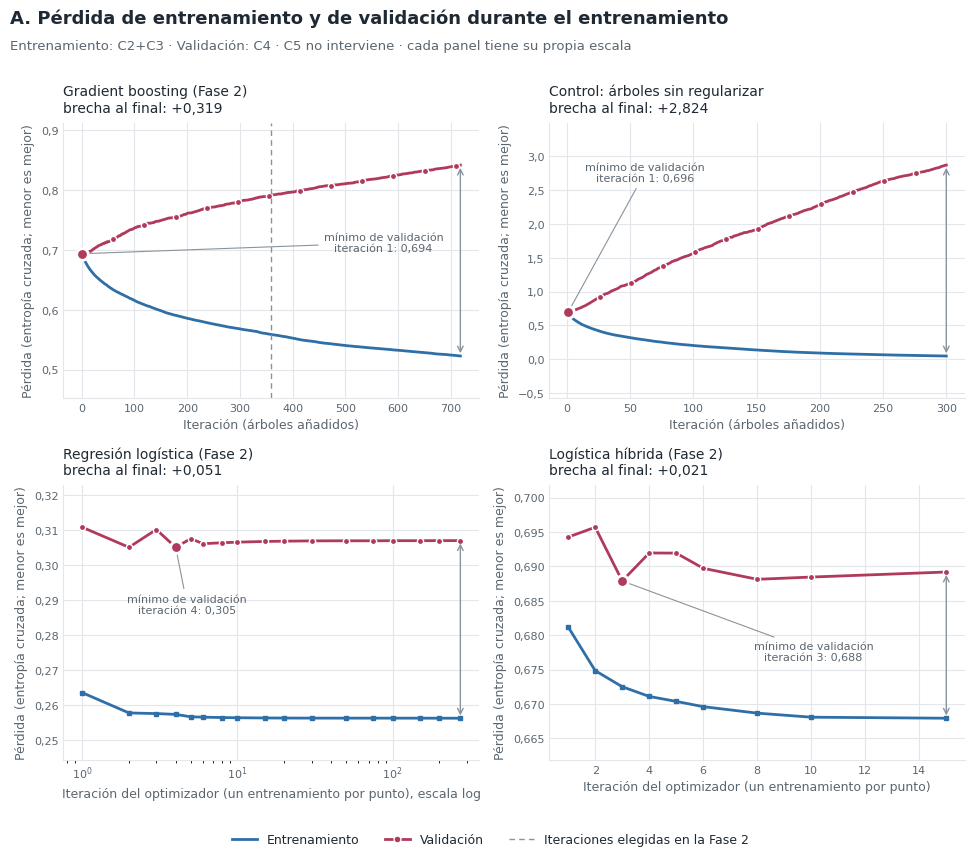

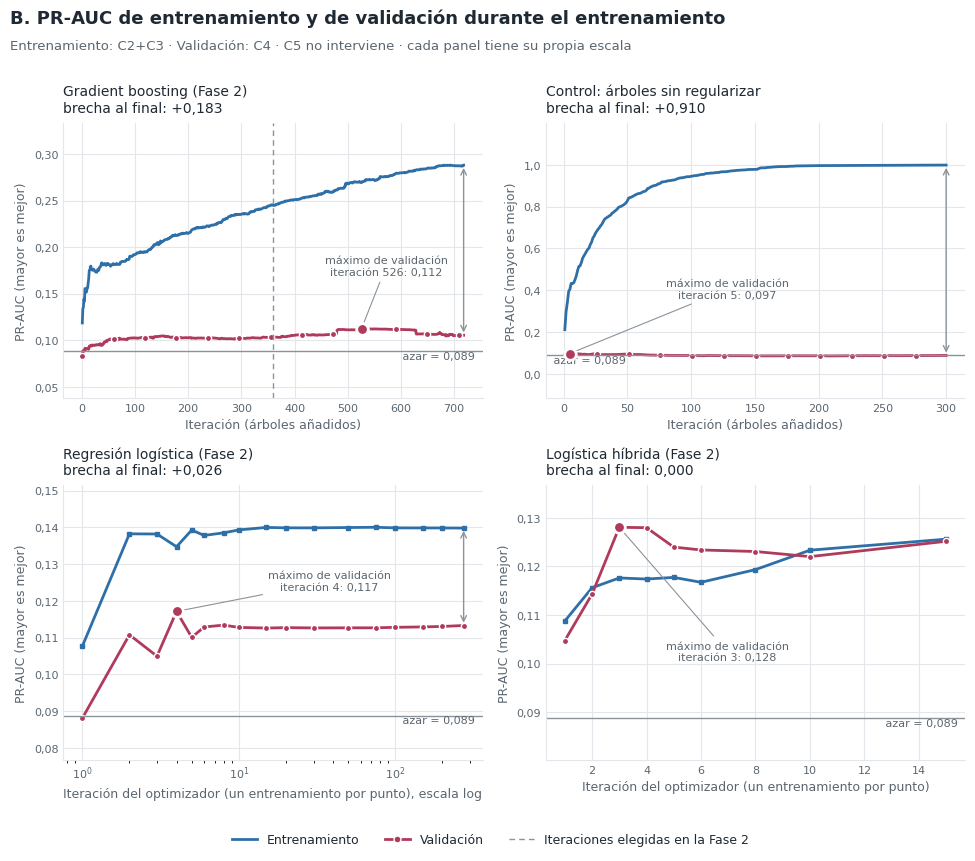

In [7]:
# @title Curvas A (pérdida) y B (PR-AUC) durante el entrenamiento
import matplotlib.pyplot as plt
from src import graficos_diagnostico as gd

fig = gd.figura_iteraciones(SEGUIMIENTO, "perdida", DIAGNOSTICO.etiqueta_tr, DIAGNOSTICO.etiqueta_val)
gd.guardar(fig, FIG / f"{FUENTE}_19_curva_perdida.png", DPI); plt.show()
fig = gd.figura_iteraciones(SEGUIMIENTO, "puntaje", DIAGNOSTICO.etiqueta_tr, DIAGNOSTICO.etiqueta_val, TASA)
gd.guardar(fig, FIG / f"{FUENTE}_20_curva_puntaje.png", DPI); plt.show()

### C. Curvas de aprendizaje por tamaño del entrenamiento (opcional, puntos extra)
`learning_curve` de scikit-learn con validación fija en C4. El entrenamiento se submuestrea varias veces; la banda muestra cuánto cambia el resultado según qué estudiantes entran en la submuestra.

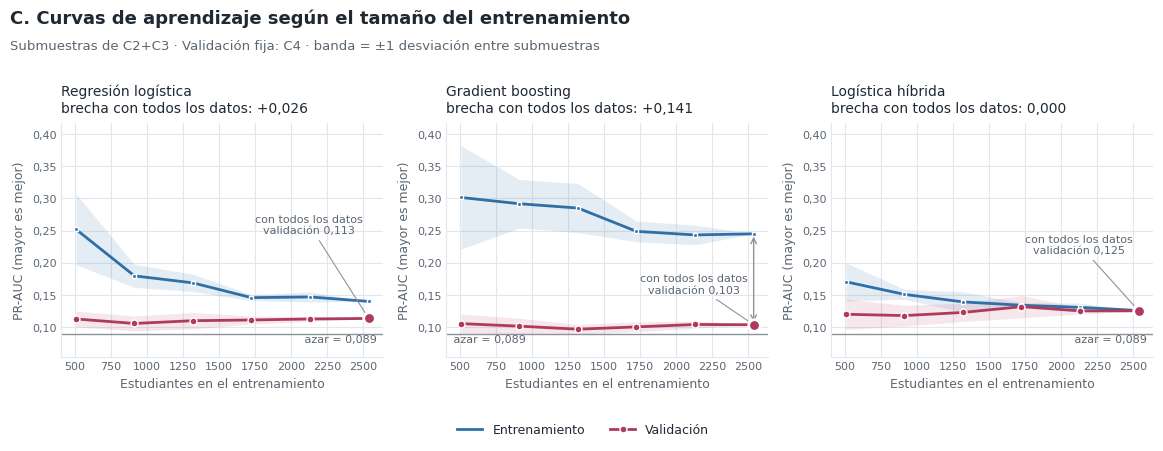

In [8]:
# @title Curva C · por tamaño del entrenamiento
CURVA_TAMANO = pd.concat([
    dg.curva_por_tamano(tipo, PARAMETROS[tipo], DIAGNOSTICO, SEMILLA,
                        fracciones=tuple(UMBRALES["fracciones_entrenamiento"]),
                        repeticiones=UMBRALES["repeticiones"])
    for tipo in ("logistica", "arboles", "hibrido")], ignore_index=True)
CURVA_TAMANO.to_csv(MET / f"curvas_tamano_{FUENTE}.csv", index=False, float_format="%.6f")
fig = gd.figura_tamano(CURVA_TAMANO, DIAGNOSTICO.etiqueta_tr, DIAGNOSTICO.etiqueta_val, TASA)
gd.guardar(fig, FIG / f"{FUENTE}_21_curva_tamano.png", DPI); plt.show()

### D. Curvas de validación por hiperparámetro (opcional, puntos extra)
`validation_curve` de scikit-learn. En las regresiones logísticas varía `C` (menos regularización hacia la derecha); en el gradient boosting varía la tasa de aprendizaje (más capacidad de ajuste hacia la derecha). El resto de hiperparámetros queda como en la Fase 2.

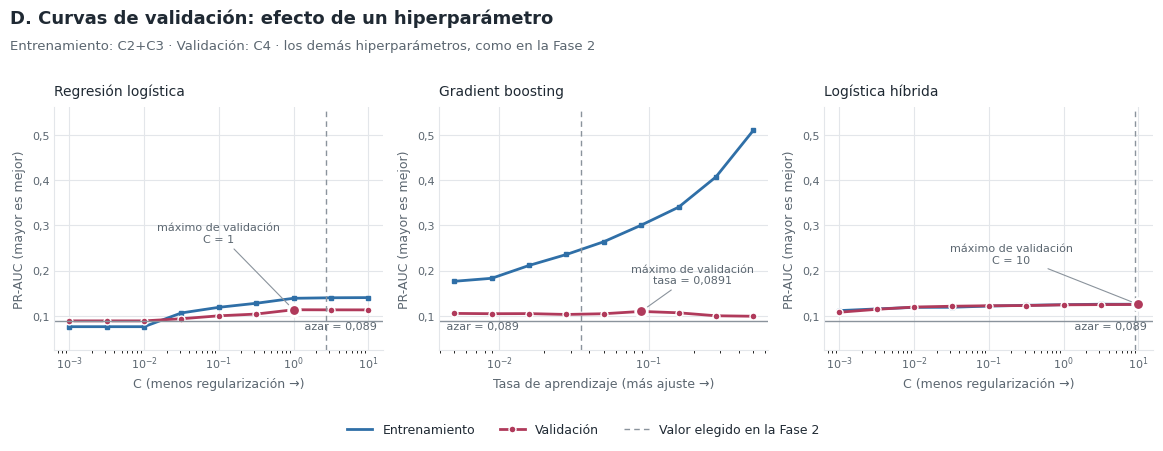

In [9]:
# @title Curva D · por hiperparámetro
valores_c = [float(v) for v in np.logspace(-3, 1, 9)]
valores_tasa = [float(v) for v in np.logspace(-2.3, -0.3, 9)]
CURVA_HIPER = pd.concat([
    dg.curva_por_hiperparametro("logistica", PARAMETROS["logistica"], DIAGNOSTICO, SEMILLA, "C", valores_c),
    dg.curva_por_hiperparametro("arboles", PARAMETROS["arboles"], DIAGNOSTICO, SEMILLA,
                                "learning_rate", valores_tasa),
    dg.curva_por_hiperparametro("hibrido", PARAMETROS["hibrido"], DIAGNOSTICO, SEMILLA, "C", valores_c),
], ignore_index=True)
CURVA_HIPER.to_csv(MET / f"curvas_hiperparametros_{FUENTE}.csv", index=False, float_format="%.6f")
fig = gd.figura_hiperparametros(CURVA_HIPER, DIAGNOSTICO.etiqueta_tr, DIAGNOSTICO.etiqueta_val, TASA)
gd.guardar(fig, FIG / f"{FUENTE}_22_curva_hiperparametros.png", DPI); plt.show()

## 5. Análisis y diagnóstico detallado
### 5.1 Patrones que se buscan en las curvas

| Diagnóstico | Qué se ve en las curvas | Cómo se mide aquí |
|---|---|---|
| **Sobreajuste** | La brecha entre entrenamiento y validación crece; el entrenamiento sigue mejorando y la validación se estanca o empeora | Brecha relativa de PR-AUC mayor que el umbral; la pérdida de validación sube después de su mínimo |
| **Subajuste** | Las dos curvas quedan juntas pero en un nivel pobre | Brecha pequeña y PR-AUC de validación por debajo del mínimo sobre el azar |
| **Ajuste adecuado** | Brecha pequeña y estable; ambas curvas convergen en un nivel útil | Ninguna de las dos condiciones anteriores |

### 5.2 Análisis cuantitativo
Los umbrales están en `config.yaml` (sección `diagnostico`). Son **reglas prácticas, no pruebas estadísticas**. Se fijaron el 2 de octubre de 2026, antes de ejecutar este cuaderno con datos reales, pero cuando ya se conocían las PR-AUC de entrenamiento y de C4 de la Fase 2. Limitación: la brecha compara la PR-AUC de dos conjuntos cuya tasa de eventos puede ser distinta; por eso la tabla muestra también cuántas veces supera al azar cada conjunto.

In [10]:
# @title Diagnóstico por modelo y medidas de las curvas
print(f"Umbrales: brecha relativa > {n(100 * UMBRALES['brecha_relativa_max'], 0)} % → sobreajuste; "
      f"si no, PR-AUC de validación < {n(UMBRALES['mejora_minima_sobre_azar'], 1)} × azar → subajuste.")
vista = DIAG[["modelo", "rol", "puntaje_entrenamiento", "puntaje_validacion", "brecha", "brecha_relativa",
              "veces_azar_entrenamiento", "mejora_sobre_azar", "lift_k_validacion", "diagnostico"]]
display(vista.rename(columns={"mejora_sobre_azar": "veces_azar_validacion"}).round(3))
DIAG.to_csv(MET / f"diagnostico_modelos_{FUENTE}.csv", index=False, float_format="%.6f")

RESUMENES = {nombre: dg.resumen_seguimiento(tabla, UMBRALES) for nombre, tabla in SEGUIMIENTO.items()}
display(pd.DataFrame(RESUMENES).T[["iteraciones", "iteracion_optima", "minimo_en_el_limite",
                                   "perdida_validacion_minima", "deterioro_perdida", "validacion_empeora",
                                   "brecha_crece", "iteracion_mejor_puntaje", "mejor_puntaje_validacion"]])

GANANCIA = dg.ganancia_por_datos(CURVA_TAMANO)
print("\n¿Ayudaría tener más datos? Validación con la mitad y con todo el entrenamiento:")
display(GANANCIA.round(4))

Umbrales: brecha relativa > 30 % → sobreajuste; si no, PR-AUC de validación < 1,5 × azar → subajuste.


,modelo,rol,puntaje_entrenamiento,puntaje_validacion,brecha,brecha_relativa,veces_azar_entrenamiento,veces_azar_validacion,lift_k_validacion,diagnostico
0,Regresión logística,Fase 2,0.140,0.113,0.026,0.190,1.841,1.276,1.396,subajuste
1,Gradient boosting,Fase 2,0.245,0.103,0.141,0.577,3.225,1.166,1.064,sobreajuste
2,Logística híbrida,Fase 2,0.126,0.125,0.000,0.003,1.654,1.410,1.529,subajuste
3,Control: árboles sin regularizar,control,0.998,0.088,0.910,0.912,13.146,0.992,0.997,sobreajuste
4,Control: logística sobrerregularizada,control,0.076,0.089,-0.013,-0.169,1.000,1.000,1.064,subajuste


,iteraciones,iteracion_optima,minimo_en_el_limite,perdida_validacion_minima,deterioro_perdida,validacion_empeora,brecha_crece,iteracion_mejor_puntaje,mejor_puntaje_validacion
Gradient boosting (Fase 2),718,1,False,0.693658,0.148205,True,True,526,0.112488
Control: árboles sin regularizar,300,1,False,0.696082,2.174893,True,True,5,0.097342
Regresión logística (Fase 2),273,4,False,0.305036,0.001914,False,False,4,0.117154
Logística híbrida (Fase 2),15,3,False,0.687891,0.001302,False,False,3,0.128043



¿Ayudaría tener más datos? Validación con la mitad y con todo el entrenamiento:


,modelo,n_mitad,n_todo,validacion_mitad,validacion_todo,ganancia,variacion_entre_submuestras,concluyente,brecha_con_todo
0,Regresión logística,1321,2541,0.1098,0.1133,0.0035,0.0127,False,0.0265
1,Gradient boosting,1321,2541,0.0966,0.1035,0.0069,0.0073,False,0.1415
2,Logística híbrida,1321,2541,0.1227,0.1252,0.0025,0.0142,False,0.0004


In [11]:
# @title Lectura del diagnóstico (generada con los resultados)
frases = dg.conclusiones(DIAG, RESUMENES, None, DIAGNOSTICO.etiqueta_val)
for titulo, clave in [("Modelos de la Fase 2", "modelos"), ("Modelos de control", "controles"),
                      ("Curvas durante el entrenamiento", "curvas")]:
    print(f"\n{titulo}")
    for frase in frases[clave]:
        print("  •", frase)
print("\n¿Más datos?")
for g in GANANCIA.itertuples():
    veredicto = ("la diferencia supera el doble de la variación entre submuestras" if g.concluyente else
                 "la diferencia no llega al doble de la variación entre submuestras: no es concluyente")
    print(f"  • {g.modelo}: de {n(g.validacion_mitad)} a {n(g.validacion_todo)} "
          f"({n(g.ganancia, signo=True)}; variación ±{n(g.variacion_entre_submuestras)}); {veredicto}.")


Modelos de la Fase 2
  • Regresión logística: subajuste (no capta señal suficiente: rinde poco en ambos conjuntos). PR-AUC de 0,140 en entrenamiento y 0,113 en C4; brecha de 0,026 (19 % del entrenamiento); 1,28 veces el azar en C4.
  • Gradient boosting: sobreajuste (memoriza el entrenamiento y pierde rendimiento con datos nuevos). PR-AUC de 0,245 en entrenamiento y 0,103 en C4; brecha de 0,141 (58 % del entrenamiento); 1,17 veces el azar en C4.
  • Logística híbrida: subajuste (no capta señal suficiente: rinde poco en ambos conjuntos). PR-AUC de 0,126 en entrenamiento y 0,125 en C4; brecha de 0,000 (0 % del entrenamiento); 1,41 veces el azar en C4.

Modelos de control
  • Control: árboles sin regularizar: sobreajuste (memoriza el entrenamiento y pierde rendimiento con datos nuevos). PR-AUC de 0,998 en entrenamiento y 0,088 en C4; brecha de 0,910 (91 % del entrenamiento); 0,99 veces el azar en C4.
  • Control: logística sobrerregularizada: subajuste (no capta señal suficiente: rinde p

## 6. Implementación de estrategias de mejora
Se implementan y evalúan **seis** estrategias (la actividad pide al menos dos). Todas se miden en la misma partición (entrenamiento → C4).

| Estrategia | Contra | Qué cambia |
|---|---|---|
| **E1** · Regularización y menor complejidad | Sobreajuste | Del control sin regularizar al gradient boosting que eligió Optuna. El punto de partida es un control, no un candidato: mide el efecto de la regularización que la Fase 2 ya aplicó |
| **E2** · Parada temprana | Sobreajuste | Menos iteraciones, elegidas por menor pérdida en la **validación interna**. Solo puede recortar el entrenamiento |
| **E3** · Modelo más simple | Sobreajuste | Menos complejidad (árboles de dos niveles, cuatro hojas, hojas grandes y L2 alta) con las mismas iteraciones |
| **E4** · Ingeniería de variables | Subajuste | De la regresión logística a la logística híbrida con las señales de la regla D2. Cambian las variables y también los hiperparámetros |
| **E5** · Menos regularización | Subajuste | `C` diez veces mayor en la regresión logística |
| **E6** · Más entrenamiento | Subajuste | El doble de iteraciones en el gradient boosting |

Las palabras «mejora» y «empeora» se refieren a la **PR-AUC de validación**; un cambio menor que el mínimo de `config.yaml` (`cambio_minimo`) se informa como «sin cambio apreciable». El Lift@k, la métrica principal del proyecto, se muestra al lado porque puede moverse en otro sentido. Si el modelo de partida no tenía el problema que la estrategia busca corregir, el resultado se lee como una comprobación.

In [12]:
# @title Aplicar las estrategias
ESTRATEGIAS = dg.evaluar_estrategias(PARAMETROS, DIAGNOSTICO, INTERNA, SEMILLA, K, UMBRALES)
ESTRATEGIAS.to_csv(MET / f"estrategias_mejora_{FUENTE}.csv", index=False, float_format="%.6f")
for e in ESTRATEGIAS.itertuples():
    print(f"{e.estrategia} (contra el {e.problema})\n   {e.modelo_antes} → {e.modelo_despues} | {e.cambio}")

E1 · Regularización y menor complejidad (contra el sobreajuste)
   Control: árboles sin regularizar → Gradient boosting | búsqueda con Optuna (Fase 2): tasa de aprendizaje 0,1 → 0,0351; profundidad sin límite → 3; mínimo de muestras por hoja 5 → 101; L2 0 → 4,25
E2 · Parada temprana (contra el sobreajuste)
   Gradient boosting → Gradient boosting | iteraciones: 359 → 20, elegidas por pérdida en la validación interna
E3 · Modelo más simple (contra el sobreajuste)
   Gradient boosting → Gradient boosting | profundidad 3 → 2; hojas 6 → 4; L2 4,25 → 10; mismas iteraciones
E4 · Ingeniería de variables (contra el subajuste)
   Regresión logística → Logística híbrida | logística híbrida con las señales de D2 (pago tardío, reserva extraordinaria, atrasos por tramos); usa sus propios hiperparámetros de la Fase 2
E5 · Menos regularización (contra el subajuste)
   Regresión logística → Regresión logística | C: 2,75 → 27,5
E6 · Más entrenamiento (contra el subajuste)
   Gradient boosting → Gradien

## 7. Comparación antes/después de mejoras

,estrategia,puntaje_validacion_antes,puntaje_validacion_despues,efecto_validacion,brecha_antes,brecha_despues,efecto_brecha,lift_k_validacion_antes,lift_k_validacion_despues,diagnostico_antes,diagnostico_despues,aplica_al_diagnostico,modelo_sin_cambios
0,E1 · Regularización y menor complejidad,0.088,0.103,mejora,0.910,0.141,reduce,0.997,1.064,sobreajuste,sobreajuste,True,False
1,E2 · Parada temprana,0.103,0.095,empeora,0.141,0.080,reduce,1.064,0.798,sobreajuste,sobreajuste,True,False
2,E3 · Modelo más simple,0.103,0.107,sin cambio apreciable,0.141,0.087,reduce,1.064,0.931,sobreajuste,sobreajuste,True,False
3,E4 · Ingeniería de variables,0.113,0.125,mejora,0.026,0.000,reduce,1.396,1.529,subajuste,subajuste,True,False
4,E5 · Menos regularización,0.113,0.113,sin cambio apreciable,0.026,0.027,sin cambio apreciable,1.396,1.462,subajuste,subajuste,True,False
5,E6 · Más entrenamiento,0.103,0.105,sin cambio apreciable,0.141,0.183,aumenta,1.064,0.864,sobreajuste,sobreajuste,False,False


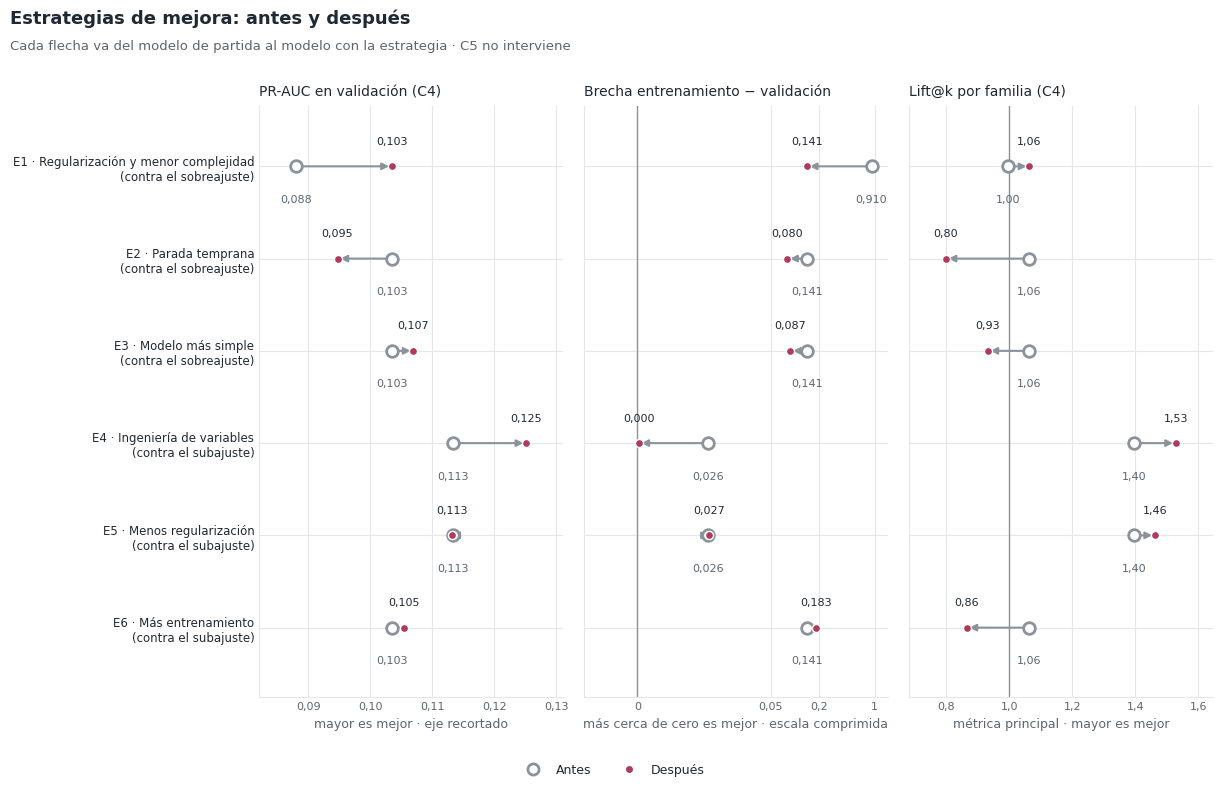

Lectura de cada estrategia (generada con los resultados):
  • E1 · Regularización y menor complejidad: PR-AUC en C4 de 0,088 a 0,103 (+0,015: la PR-AUC mejora); brecha de +0,910 a +0,141 (se reduce); Lift@k de 1,00 a 1,06.
  • E2 · Parada temprana: PR-AUC en C4 de 0,103 a 0,095 (−0,009: la PR-AUC empeora); brecha de +0,141 a +0,080 (se reduce); Lift@k de 1,06 a 0,80.
  • E3 · Modelo más simple: PR-AUC en C4 de 0,103 a 0,107 (+0,003: PR-AUC sin cambio apreciable); brecha de +0,141 a +0,087 (se reduce); Lift@k de 1,06 a 0,93.
  • E4 · Ingeniería de variables: PR-AUC en C4 de 0,113 a 0,125 (+0,012: la PR-AUC mejora); brecha de +0,026 a 0,000 (se reduce); Lift@k de 1,40 a 1,53.
  • E5 · Menos regularización: PR-AUC en C4 de 0,113 a 0,113 (0,000: PR-AUC sin cambio apreciable); brecha de +0,026 a +0,027 (sin cambio apreciable); Lift@k de 1,40 a 1,46.
  • E6 · Más entrenamiento: PR-AUC en C4 de 0,103 a 0,105 (+0,002: PR-AUC sin cambio apreciable); brecha de +0,141 a +0,183 (aumenta); Lift@k d

In [13]:
# @title Tabla y figura de antes y después
columnas = ["estrategia", "puntaje_validacion_antes", "puntaje_validacion_despues", "efecto_validacion",
            "brecha_antes", "brecha_despues", "efecto_brecha", "lift_k_validacion_antes",
            "lift_k_validacion_despues", "diagnostico_antes", "diagnostico_despues",
            "aplica_al_diagnostico", "modelo_sin_cambios"]
display(ESTRATEGIAS[columnas].round(3))
fig = gd.figura_estrategias(ESTRATEGIAS, DIAGNOSTICO.etiqueta_val)
gd.guardar(fig, FIG / f"{FUENTE}_23_estrategias.png", DPI); plt.show()

CONCLUSIONES = dg.conclusiones(DIAG, RESUMENES, ESTRATEGIAS, DIAGNOSTICO.etiqueta_val)
print("Lectura de cada estrategia (generada con los resultados):")
for frase in CONCLUSIONES["estrategias"]:
    print("  •", frase)

## 8. Conclusiones y reflexiones
Las frases siguientes se generan con los resultados de esta ejecución, de modo que siempre coinciden con las tablas y las figuras.

In [14]:
# @title Conclusiones de esta ejecución
print("Balance")
for frase in CONCLUSIONES["balance"]:
    print("  •", frase)

resultado = {
    "fuente": FUENTE, "cohortes_entrenamiento": COHORTES, "validacion": DIAGNOSTICO.etiqueta_val,
    "particiones": [DIAGNOSTICO.resumen(), INTERNA.resumen()], "k_por_sede": K,
    "tasa_validacion": TASA, "umbrales": {k: UMBRALES[k] for k in dg.UMBRALES},
    "repeticiones": UMBRALES["repeticiones"], "comprobacion_fase2": COMPROBACION,
    "parametros_fase2": PARAMETROS, "controles": {nombre: p for nombre, (_, p) in CONTROLES.items()},
    "resumen_seguimiento": RESUMENES, "ganancia_por_datos": GANANCIA.to_dict("records"),
    "conclusiones": CONCLUSIONES,
}
(MET / f"diagnostico_semana3_{FUENTE}.json").write_text(
    json.dumps(resultado, indent=2, ensure_ascii=False, default=float), encoding="utf-8")
print("\nGuardado:", f"diagnostico_semana3_{FUENTE}.json")

Balance
  • Modelos de la Fase 2 por diagnóstico: 2 con subajuste, 1 con sobreajuste.
  • Efecto de las 6 estrategias sobre la PR-AUC en C4: mejora en 2, empeora en 1 y no cambia de forma apreciable en 3.
  • Estrategias contra el sobreajuste que reducen la brecha: 3 de 3.
  • Este análisis usa solo las cohortes de entrenamiento y C4. C5 ya se evaluó una vez y no interviene, así que estas estrategias no cambian la decisión final del proyecto (priorizar con la regla D2).

Guardado: diagnostico_semana3_real.json


### Reflexiones
1. **El diagnóstico depende de con qué se compara.** Una brecha pequeña no basta: un modelo puede ser estable y aun así no superar al azar. Por eso se miden dos cosas, la brecha y la mejora sobre el azar.
2. **Reducir la brecha y mejorar la validación son cosas distintas.** La regularización, la parada temprana y los modelos simples buscan reducir la brecha y no añaden información nueva; que lo consigan depende del caso. La tabla de la sección 7 muestra las dos medidas por separado para no confundirlas.
3. **Con pocos eventos, los resultados se mueven.** Las bandas de la curva C muestran cuánto cambia la validación según qué estudiantes entran en el entrenamiento. Además las tasas cambian entre ciclos, algo que una sola cohorte de validación no permite medir.
4. **Límites de este análisis.** Las estrategias se compararon en C4, que ya se usó para seleccionar y calibrar en la Fase 2; una diferencia pequeña en C4 puede ser ruido. Los umbrales son reglas prácticas. C5 no se volvió a usar, así que ninguna estrategia cambia la decisión final del proyecto: la priorización sigue siendo la regla D2.
5. **Qué haríamos con una cohorte nueva.** Repetir este diagnóstico cada mayo, cuando se conozca el resultado del ciclo, y evaluar en esa cohorte nueva las estrategias que aquí mejoraron la validación, porque esa cohorte no habrá participado en ninguna decisión.

El reporte técnico de esta actividad está en `docs/diagnostic_report.pdf`.

In [15]:
# @title Descargar agregados para compartir (Colab)
# Solo métricas y figuras agregadas: no contiene datos individuales.
import shutil
paquete = RAIZ / f"diagnostico_{FUENTE}"
shutil.rmtree(paquete, ignore_errors=True); paquete.mkdir()
for nombre in [f"curvas_seguimiento_{FUENTE}.csv", f"curvas_tamano_{FUENTE}.csv",
               f"curvas_hiperparametros_{FUENTE}.csv", f"diagnostico_modelos_{FUENTE}.csv",
               f"estrategias_mejora_{FUENTE}.csv", f"diagnostico_semana3_{FUENTE}.json"]:
    shutil.copy(MET / nombre, paquete)
for png in sorted(FIG.glob(f"{FUENTE}_19_*.png")) + sorted(FIG.glob(f"{FUENTE}_2[0-3]_*.png")):
    shutil.copy(png, paquete)
zip_final = shutil.make_archive(str(paquete), "zip", paquete)
shutil.rmtree(paquete)
print("Contenido:", sorted(zipfile.ZipFile(zip_final).namelist()))
if EN_COLAB:
    from google.colab import files
    files.download(zip_final)

Contenido: ['curvas_hiperparametros_real.csv', 'curvas_seguimiento_real.csv', 'curvas_tamano_real.csv', 'diagnostico_modelos_real.csv', 'diagnostico_semana3_real.json', 'estrategias_mejora_real.csv', 'real_19_curva_perdida.png', 'real_20_curva_puntaje.png', 'real_21_curva_tamano.png', 'real_22_curva_hiperparametros.png', 'real_23_estrategias.png']
